# Обнаружение болезни паркинсона с помощью XGBoost

Твоя задача с помощью Data Science предсказать заболевание паркинсона на ранней стадии, используя алгоритм машинного обучения XGBoost и библиотеку sklearn для нормализации признаков. Как это сделать? Тебя  придется самостоятельно изучить данный вопрос.

Используй следующий [датасет UCI ML Parkinsons](https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data). Описание признаков и меток датасета представлены [здесь](https://storage.yandexcloud.net/academy.ai/practica/parkinsons.names). От тебя  требуется помимо создания самой модели получить ее точность на тестовой выборке. Выборки делить в соотношении 80% обучающая, 20% - тестовая.

Дополнительные баллы ты получишь, если сможешь получить точность более 95%.

Если при обучении модели в Colab ошибка "sklearn_tags" - использовать библиотеку scikit-learn версии 1.1

`!pip install scikit-learn==1.1`

In [170]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import Normalizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
# 1. Загрузка данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
data = pd.read_csv(url)

Разделение признаков и целевой переменной:

Признаки (X) включают все столбцы, кроме status (целевой переменной) и name (идентификатор пациента).

Целевая переменная (y) хранит информацию о наличии или отсутствии болезни Паркинсона.

In [172]:
# 2. Разделение признаков и меток
X = data.drop(columns=['status', 'name'])  # Признаки
y = data['status']  # Целевая переменная

Посмотрим как распределены классы здоровых и больных пациентов.

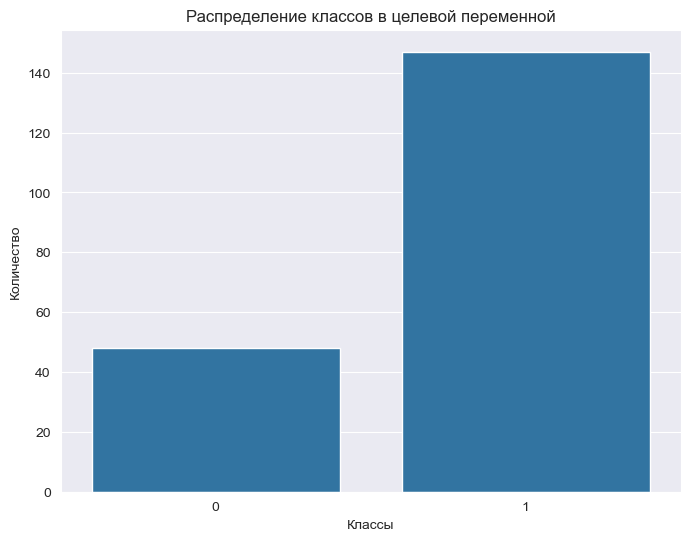

In [173]:
# 3. Визуализация дисбаланса классов
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title("Распределение классов в целевой переменной")
plt.xlabel("Классы")
plt.ylabel("Количество")
plt.show()

In [174]:
# 4. Нормализация данных
scaler = Normalizer()
X_scaled = scaler.fit_transform(X)

Так как у нас дисбаланс классов, то мы применяем SMOTE для балансировки. Это поможет модели лучше обучиться.

In [175]:
# 5. Балансировка классов с использованием SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

Оставляем 20% данных для тестовой выборки.

In [176]:
# 6. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

Используем модель XGBoost с метрикой логарифмических потерь logloss.

In [177]:
# 7. Модель XGBoost
model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

Для поиска оптимальных гиперпараметров используем метод GridSearchCV.

Так же сделаем вывод оптимальных гиперпараметров.

In [178]:
# 8. Оптимизация гиперпараметров с помощью GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Лучшие параметры
best_params = grid_search.best_params_
print(f"Лучшие параметры: {best_params}")

Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50, 'subsample': 1.0}


In [179]:
# 9. Обучение модели с оптимальными параметрами
best_model = grid_search.best_estimator_

Использование кросс-валидации позволяет лучше оценить точность модели на разных подмножествах данных.

In [180]:
# 10. Кросс-валидация
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Средняя точность по кросс-валидации: {np.mean(cv_scores) * 100:.2f}%")

Средняя точность по кросс-валидации: 91.49%


In [181]:
# 11. Предсказания на тестовых данных
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

Оценка модели:

Точность: процент правильно предсказанных значений на тестовой выборке.

ROC-AUC: метрика, показывающая способность модели разделять классы.

Отчет по классификации: включает показатели точности, полноты и F1-меры.

In [182]:
# 12. Оценка модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Точность модели: {accuracy * 100:.2f}%")
print(f"ROC-AUC: {roc_auc:.2f}")

# Отчет по классификации
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred))

Точность модели: 96.61%
ROC-AUC: 1.00

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.93      0.96        29

    accuracy                           0.97        59
   macro avg       0.97      0.97      0.97        59
weighted avg       0.97      0.97      0.97        59



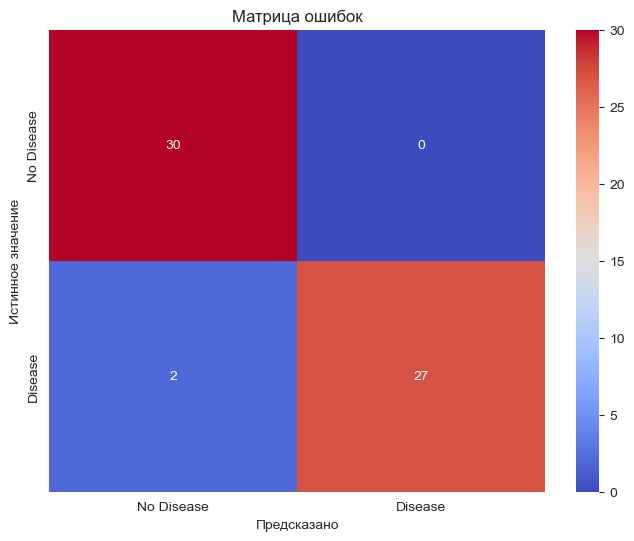

In [183]:
# 13. Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.title('Матрица ошибок')
plt.show()

Визуализация важности признаков:

plot_importance из XGBoost показывает, какие признаки наиболее важны для модели. Это помогает понять, какие параметры больше всего влияют на результат.

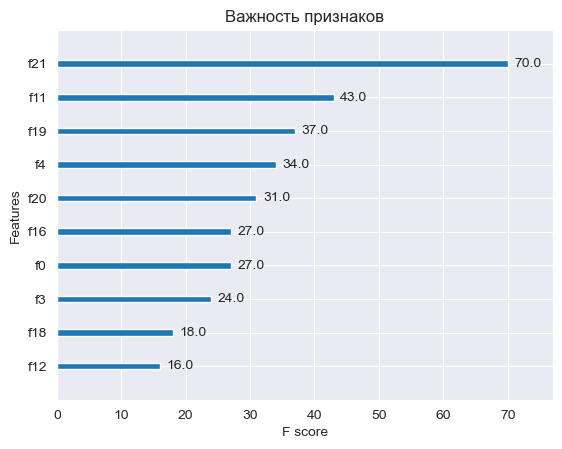

In [184]:
# 14. Важность признаков
xgb.plot_importance(best_model, max_num_features=10)
plt.title("Важность признаков")
plt.show()

In [185]:
# Примеры предсказаний
num_examples = 5  # Количество примеров для отображения
sample_indices = np.random.choice(range(X_test.shape[0]), size=num_examples, replace=False)

print("\nПримеры предсказаний модели:")
for i, idx in enumerate(sample_indices):
    print(f"\nПример {i + 1}:")
    print(f"Данные: {X_test[idx]}")
    print(f"Истинная метка: {y_test.iloc[idx]}")
    print(f"Предсказанная метка: {y_pred[idx]}")
    print(f"Вероятность предсказания (положительный класс): {y_pred_proba[idx]:.2f}")


Примеры предсказаний модели:

Пример 1:
Данные: [ 5.58193361e-01  6.33072490e-01  5.27748635e-01  1.83100879e-05
  1.44173920e-07  8.69849319e-06  1.11494498e-05  2.60474216e-05
  1.45423428e-04  1.28314789e-03  7.27597718e-05  8.70810479e-05
  1.33120586e-04  2.18327373e-04  8.78019175e-05  9.03537959e-02
  3.00271504e-03  3.34507044e-03 -2.81925229e-02  1.12008719e-03
  1.17532790e-02  8.89000422e-04]
Истинная метка: 1
Предсказанная метка: 1
Вероятность предсказания (положительный класс): 0.98

Пример 2:
Данные: [ 5.67249630e-01  6.17174298e-01  5.35417360e-01  4.55486132e-05
  3.76434820e-07  2.17861652e-05  3.52907644e-05  6.53114412e-05
  2.21202511e-04  2.14567847e-03  1.09542533e-04  1.65913647e-04
  1.52597265e-04  3.28674652e-04  5.75004187e-05  1.00592795e-01
  1.95540949e-03  3.88230875e-03 -1.99645359e-02  1.40744744e-03
  1.02934219e-02  1.68348710e-03]
Истинная метка: 1
Предсказанная метка: 1
Вероятность предсказания (положительный класс): 0.99

Пример 3:
Данные: [ 6.453